In [43]:
# Import dependencies for analysis

from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt


## Import Experimental Data

In [44]:
# Load data into dataframes

home = Path().resolve()

permeance = counter = pd.read_csv(f"{home}/data/permeance_data_collection.csv")
hybrid = pd.read_csv(f"{home}/data/air_separation_run_1.csv")
counter = pd.read_csv(f"{home}/data/air_separation_counter_current_run_1.csv")
co = pd.read_csv(f"{home}/data/air_separation_co_current_run_1.csv")

## Permeance and Selectivity Calculations

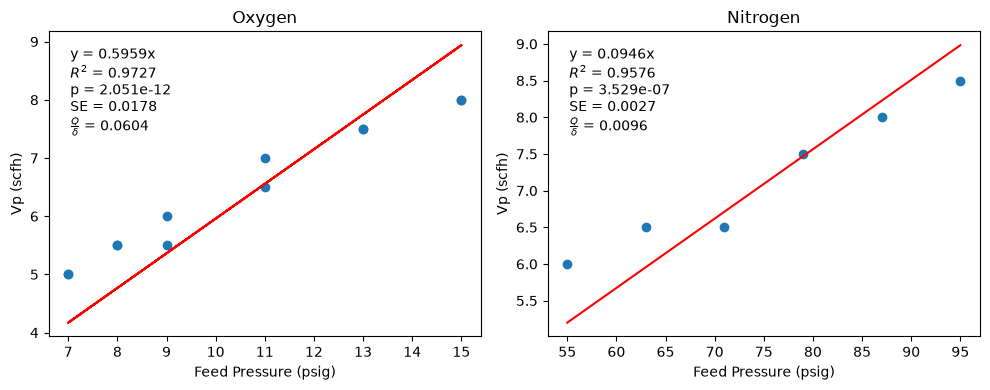

In [51]:
# Calculate permeance and selectivities from permeance dataframe

# Constrained linear regression function (y = mx)
def linest(x: pd.Series, y: pd.Series) -> tuple:
    """
    Linear least-squares regression forced through the origin: y = m*x.

    Returns:
        (slope, intercept, rvalue, pvalue, stderr, intercept_stderr)

    Notes:
        - intercept is always 0.0 because the model is constrained through
          the origin.
        - rvalue is the ordinary Pearson correlation coefficient, matching
          the meaning of scipy.stats.linregress().rvalue.
        - pvalue tests H0: slope = 0 for the no-intercept regression.
        - intercept_stderr is NaN because the intercept is fixed, not estimated.
    """

    # Put x and y together and remove paired NaN values
    data = pd.concat([x, y], axis=1).dropna()

    x = data.iloc[:, 0].to_numpy(dtype=float)
    y = data.iloc[:, 1].to_numpy(dtype=float)

    n = len(x)

    if n < 2:
        raise ValueError("At least two valid x-y pairs are required.")

    # ----- slope for y = mx -----
    sum_x2 = np.sum(x**2)

    if sum_x2 == 0:
        raise ValueError("Cannot perform regression when all x values are zero.")

    slope = np.sum(x * y) / sum_x2

    # ----- intercept -----
    intercept = 0.0

    # ----- residuals -----
    y_pred = slope * x
    residuals = y - y_pred

    # One fitted parameter: slope
    df = n - 1

    # Residual variance
    sse = np.sum(residuals**2)
    mse = sse / df

    # ----- standard error of slope -----
    stderr = np.sqrt(mse / sum_x2)

    # ----- hypothesis test H0: slope = 0 -----
    if stderr == 0:
        if slope == 0:
            pvalue = 1.0
        else:
            pvalue = 0.0
    else:
        t_stat = slope / stderr
        pvalue = 2 * stats.t.sf(np.abs(t_stat), df)

    # ----- Pearson correlation coefficient -----
    rvalue = stats.pearsonr(x, y).statistic

    # Intercept is constrained rather than estimated
    intercept_stderr = np.nan

    return (
        slope,
        intercept,
        rvalue,
        pvalue,
        stderr,
        intercept_stderr
    )

area = 9.86 # Membrane area is 9.86 m^2

# Split into individual species dataframes
oxygen_data = permeance[permeance["Species"] == "O2"]
nitrogen_data = permeance[permeance["Species"] == "N2"]

# Convert oxygen data into long dataframe
oxygen_long = oxygen_data.melt(
    id_vars=["Species", "Feed Pressure (psig)"],
    value_vars=["Vp (scfh), Rep 1", "Vp (scfh), Rep 2"],
    var_name="Replicate",
    value_name="Vp"
)

# Linear regression of y = mx
oxy_reg = linest(oxygen_long["Feed Pressure (psig)"], oxygen_long["Vp"])
oxy_fit = oxy_reg[0] * oxygen_long["Feed Pressure (psig)"] # Make fitted values
nitro_reg = linest(nitrogen_data["Feed Pressure (psig)"], nitrogen_data["Vp (scfh), Rep 1"])
nitro_fit = nitro_reg[0] * nitrogen_data["Feed Pressure (psig)"] # Make fitted values

# Declare figures
pnsfig, pnsaxes = plt.subplots(1, 2, figsize=(10, 4))

# Plot oxygen data
pnsaxes[0].scatter(oxygen_long["Feed Pressure (psig)"], oxygen_long["Vp"])
pnsaxes[0].plot(oxygen_long["Feed Pressure (psig)"], oxy_fit, c="red")
pnsaxes[0].set_xlabel("Feed Pressure (psig)")
pnsaxes[0].set_ylabel("Vp (scfh)")
pnsaxes[0].set_title("Oxygen")
oxy_annotations = (
    f"y = {oxy_reg[0]:.4f}x\n"
    f"$R^2$ = {oxy_reg[2]**2:.4f}\n"
    f"p = {oxy_reg[3]:.3e}\n"
    f"SE = {oxy_reg[4]:.4f}\n"
    rf"$\frac{{Q}}{{\delta}}$ = {oxy_reg[0] / area:0.4f}"
)
pnsaxes[0].text(
    0.05, 0.95,
    oxy_annotations,
    transform=pnsaxes[0].transAxes,
    va="top"
)

# Plot nitrogen data
pnsaxes[1].scatter(nitrogen_data["Feed Pressure (psig)"], nitrogen_data["Vp (scfh), Rep 1"])
pnsaxes[1].plot(nitrogen_data["Feed Pressure (psig)"], nitro_fit, c="red")
pnsaxes[1].set_xlabel("Feed Pressure (psig)")
pnsaxes[1].set_ylabel("Vp (scfh)")
pnsaxes[1].set_title("Nitrogen")
oxy_annotations = (
    f"y = {nitro_reg[0]:.4f}x\n"
    f"$R^2$ = {nitro_reg[2]**2:.4f}\n"
    f"p = {nitro_reg[3]:.3e}\n"
    f"SE = {nitro_reg[4]:.4f}\n"
    rf"$\frac{{Q}}{{\delta}}$ = {nitro_reg[0] / area:0.4f}"
)
pnsaxes[1].text(
    0.05, 0.95,
    oxy_annotations,
    transform=pnsaxes[1].transAxes,
    va="top"
)

pnsfig.tight_layout()
plt.show()